The Challenge: > Given the source code of a password checker where the actual password string is masked, and knowing that the password is up to 100 characters long, the goal is to recover the secret password by executing a White-Box Timing Side-Channel Attack.

First, we will explain how the code works:
In the main program, there is a check that argc == 2 (the program name and the password).
Then it calls the verifyPassword function, which checks if the password is correct.
How is it done? First, it compares the lengths. If the entered password’s length is different from the correct one’s length, it immediately rejects it.
Then, if it has the right length, it starts to compare it to the correct password character by character.
This means that the later the first different character (between the real password and the entered one) appears, the longer it will take the program to reject the password.
We will be able to use this to discover the password.
The function usleep(10000) is included in the code to make the differences more prominent.
(On our computer, more processes and programs are running, which can affect the run time with minor timing differences; so, to make the different times distinguishable, this delay was needed.)

In [29]:
import subprocess
import time
import matplotlib.pyplot as plt
import numpy as np

To discover the password, we first tried to determine its length.
We tried passwords of different lengths to check for which one the response time was the longest.
This is because as we saw, a password of a different length from the real password is rejected almost immediately.

In [30]:
def measure_time(input_str, tries):
    timing = np.zeros(tries)
    for i in range(tries):
        start = time.perf_counter()
        subprocess.run(['./password_checker', input_str],
            stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        timing[i] = (time.perf_counter() - start)
    return np.mean(timing)

 To get accurate results, we tried each length 7 times and calculated the average.
 We found that the length 14 is the password length

In [16]:
MAX_LEN = 100
TRIES = 7

masserment = np.zeros(MAX_LEN)
for length in range(1, MAX_LEN):
    pass_len = "A" * length
    masserment[length] = measure_time(pass_len, TRIES)
length = np.argmax(masserment)
print(f"the length is {length}")

the length is 14


## plot


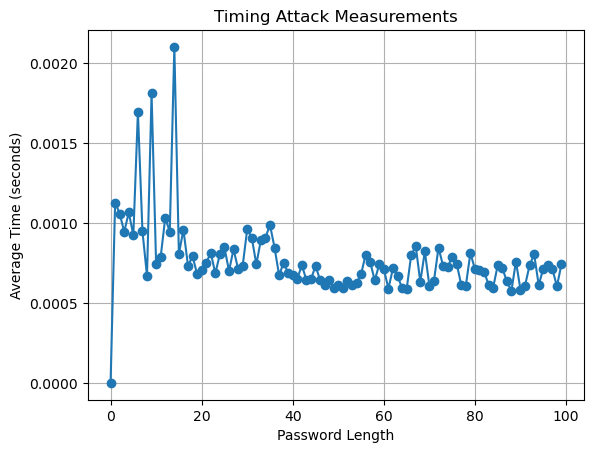

In [ ]:
plt.plot(np.arange(0,100), masserment, marker='o')
plt.xlabel('Password Length')
plt.ylabel('Average Time (seconds)')
plt.title('Timing Attack Measurements')
plt.grid(True)
plt.show()

Then we tried to run through all the letters 'a' to 'z', digits, and symbols, one by one.
We iterated over all relevant ascii values (33–126) for each index in the password. 
For each index, the character that takes the longest time to be rejected is probably the correct one (because at index i, for example, every incorrect character is rejected at index i, while the correct one is only rejected at i+1).

In [ ]:
password = ['a'] * length
for i in range(length):
    times = []
    for j in range(94):
        password[i] = chr(33 + j)
        passtorun = ''.join(password)
        times.append(measure_time(passtorun, TRIES))  
        
    jmax = np.argmax(times)
    password[i] = chr(33 + jmax)

In [33]:
final_password = ''.join(password)
print(final_password)

IL0v3H0m3w0rk!


## check 

In [34]:
result = subprocess.run(['./password_checker', final_password], capture_output=True,text=True)
print(result)

CompletedProcess(args=['./password_checker', 'IL0v3H0m3w0rk!'], returncode=0, stdout='', stderr='')


We can see that the returned code is 0, meaning that the password we found is correct.

## Bonus:

To prevent such an attack, we should make sure that calculation time does not cause data leakage — meaning it should be the same for all passwords.
 One way to do this is to compare all characters anyway (even if the first character is already different). Also, whether a character is correct or wrong, we should perform some action (mark as rejected or some other action) that takes the same amount of time.
 We also don't want the duration of time to reveal anything about the real password length (since we could otherwise discover it from the calculation time, even if all lengths are compared to the real one — shorter time might indicate a shorter password, and vice versa).
 Therefore, we might need to perform 100 comparisons anyway (or the number of comparisons according to the password length limit we set).
 Then the set of operations and their duration will be constant, and no information will leak.
